In [10]:
# Standard library imports
import os
import numpy as np

# Pytorch libraries
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
from PIL import Image
import glob

# Importing functions and classes from plotting.py,model.py, preprocessing.py
from model import SimplifiedResnet50
from preprocessing import load_dataloader
from plotting import visualize_batch, min_max_image

In [11]:
class SingleFolderDataset(Dataset):
    """Dataset to load images from a single folder without class subdirectories"""
    
    def __init__(self, folder_path, transform=None):
        """
        Args:
            folder_path (str): Path to the folder containing images
            transform (callable, optional): Transform to be applied to the images
        """
        self.folder_path = folder_path
        self.transform = transform
        # Collecting all image files from the folder
        self.image_paths = glob.glob(os.path.join(folder_path, "*.jpg")) + \
                           glob.glob(os.path.join(folder_path, "*.jpeg")) + \
                           glob.glob(os.path.join(folder_path, "*.png"))
        
        # Extracting filenames for identification
        self.filenames = [os.path.basename(path) for path in self.image_paths]
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        # Loading the image
        image = Image.open(img_path).convert('RGB')
        
        # Applying transformations if any
        if self.transform:
            image = self.transform(image)
            
        return image, self.filenames[idx]  # Returning the image and filename

In [12]:
def load_model(checkpoint_path, device):
    """
    Load a trained model from checkpoint
    
    Args:
        checkpoint_path (str): Path to the model checkpoint
        device (torch.device): Device to load the model to
        
    Returns:
        model: Loaded model
    """
    checkpoint = torch.load(checkpoint_path, map_location=device)
    num_classes = 10  # Default, will be adjusted based on the loaded model
    
    # Checking if the checkpoint has hyperparameters that include num_classes
    if "hyperparameters" in checkpoint and "num_classes" in checkpoint["hyperparameters"]:
        num_classes = checkpoint["hyperparameters"]["num_classes"]
    elif "best_hyperparameters" in checkpoint and "num_classes" in checkpoint["best_hyperparameters"]:
        num_classes = checkpoint["best_hyperparameters"]["num_classes"]
    
    # Initializing the model with the correct number of classes
    model = SimplifiedResnet50(num_classes=num_classes)
    
    # Loading the model state dictionary
    model.load_state_dict(checkpoint["model_state_dict"])
    model = model.to(device)
    model.eval()

    return model

In [13]:
def visualize_predictions(images, predictions, class_names):
    """Visualize images with predictions only"""
    num_rows = int(np.ceil(np.sqrt(len(images))))
    fig, axes = plt.subplots(num_rows, num_rows, figsize=(15, 15))
    
    for idx, ax in enumerate(axes.flat):
        if idx < len(images):
            # Normalize and show image
            normalized_image = (images[idx] - images[idx].min()) / (images[idx].max() - images[idx].min())
            ax.imshow(normalized_image)
            
            # Show prediction
            pred_label = class_names[predictions[idx]]
            ax.set_title(f"Predicted class: {pred_label}", color='blue')
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()

In [14]:
def predict_and_visualize(folder_path, checkpoint_path, batch_size=16):
    # Load model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = load_model(checkpoint_path, device)
    
    # Load class names from training data
    train_loader, _ = load_dataloader("train_dataloader.pth")
    class_names = train_loader.dataset.classes
    
    # Create dataset and dataloader
    basic_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])
    dataset = SingleFolderDataset(folder_path, transform=basic_transform)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    
    # Get normalization stats
    _, train_global_stats = load_dataloader("train_dataloader.pth")
    normalize = transforms.Normalize(
        mean=train_global_stats['mean'].tolist(),
        std=train_global_stats['std'].tolist()
    )
    
    # Prediction loop
    all_images = []
    all_predictions = []
    
    with torch.no_grad():
        for images, _ in dataloader:  # Ignore filenames for visualization
            # Store original images
            batch_images_np = images.permute(0, 2, 3, 1).cpu().numpy()
            all_images.extend(batch_images_np)
            
            # Normalize and predict
            images = torch.stack([normalize(img) for img in images]).to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_predictions.extend(predicted.cpu().numpy())
    
    # Visualize results
    visualize_predictions(all_images, all_predictions, class_names)
    return all_images, all_predictions

DataLoader loaded from train_dataloader.pth
DataLoader loaded from train_dataloader.pth


AttributeError: 'Axes' object has no attribute 'flat'

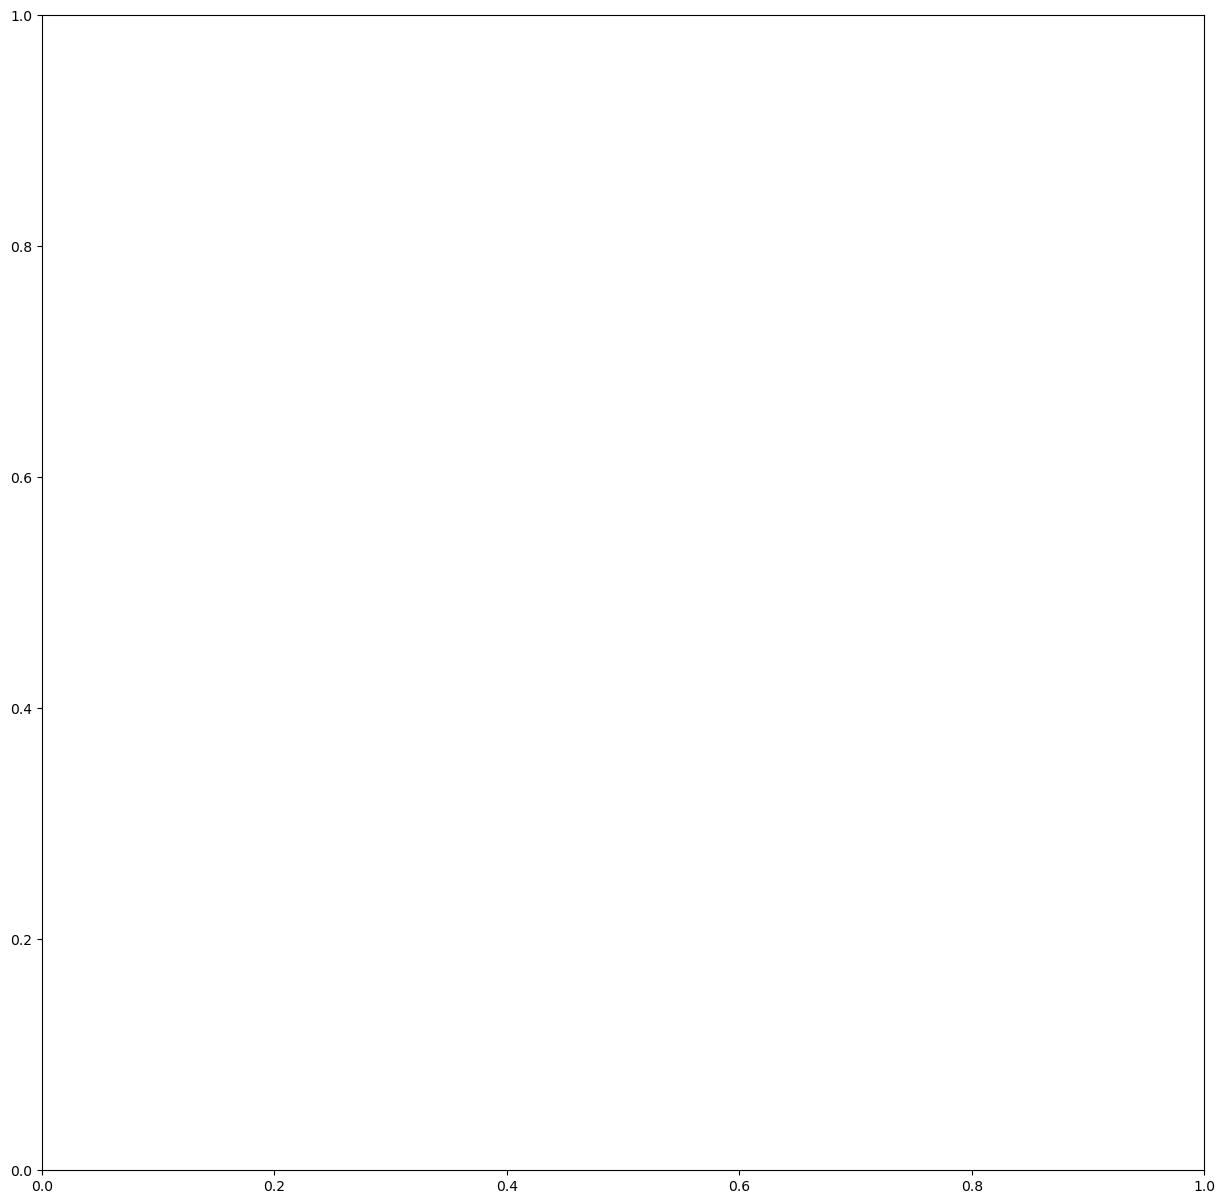

In [15]:
checkpoint_path = "../results/best_train_model.pth"
data_dir = "../random_data"  

# Run prediction and visualization
images, predictions = predict_and_visualize(folder_path=data_dir,
                                            checkpoint_path=checkpoint_path)